<div style="font-family: Arial, sans-serif; background-color: #f8f9fa; padding: 20px; border-radius: 10px; box-shadow: 0 4px 6px rgba(0, 0, 0, 0.1);">
  <div style="display: flex; justify-content: space-between; align-items: center;">
    <img src="https://sigmoidal.ai/wp-content/uploads/2024/09/Academia-Sigmoidal-Light.png" alt="Academia Sigmoidal Logo" width="250" height="auto">
    <div style="text-align: right;">
<h1 style="color: #007bff; margin: 0; font-size: 24px;">Bootcamp de Visão Computacional Aplicada a Drones</h1>
    </div>
</div>
<hr style="border: none; height: 1px; background-color: #007bff; margin: 20px 0;">
<h3 style="color: #343a40; margin: 0; font-size: 20px;"><strong>Projeto 3 · Supervision: dados, coordenadas e anotações</strong></h3>
<p style="color: #6c757d; margin: 5px 0 0; font-size: 14px;"><strong>Instrutor:</strong> Carlos Melo, MSc.</p>
</div>

# Supervision: dados, coordenadas e anotações

O objetivo é transformar previsões de um detector em dados interpretáveis e visualizações precisas. Ao final, você poderá filtrar instâncias, converter formatos de caixas, normalizar coordenadas e escolher pontos de ancoragem apropriados à aplicação.

[![Abrir o Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/#create=true)

No Colab, use **Arquivo → Fazer upload de notebook** e selecione este arquivo. Cada notebook é independente e baixa seus próprios dados de uma fonte pública. Execute as células em ordem, desde o início, em uma sessão nova. GPU é recomendada para vídeo; CPU também é selecionada automaticamente quando CUDA não está disponível.

## Preparar o ambiente

O ambiente de referência usa **Python 3.12**. As versões abaixo fixam a API usada nesta aula. A instalação deve ocorrer antes de importar as bibliotecas. Caso o Colab solicite reinicialização, reinicie a sessão e execute novamente desde o início; não misture objetos importados de versões diferentes.

In [1]:
%pip install -q torch==2.8.0 torchvision==0.23.0 \
    supervision==0.30.5 trackers==2.6.1 rfdetr==1.11.0 \
    ultralytics==8.4.163 numpy==2.3.5 transformers==5.17.0 \
    opencv-python==5.0.0.93 imageio-ffmpeg==0.6.0 \
    matplotlib==3.10.7 pandas==2.3.3

Note: you may need to restart the kernel to use updated packages.


## Importar as ferramentas

**RF-DETR** estima caixas, classes e pontuações. **Supervision**, abreviado como `sv`, organiza os resultados, manipula sua geometria e produz visualizações. Os arrays lidos com OpenCV usam a ordem de canais **BGR**; a entrada NumPy do RF-DETR usa **RGB**.

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import supervision as sv
import torch
from pathlib import Path
from urllib.request import urlretrieve
from importlib.metadata import version
from rfdetr import RFDETRMedium
plt.rcParams.update({"font.family": "sans-serif", "font.size": 12,
                     "figure.figsize": (12, 7), "axes.grid": False})
np.set_printoptions(precision=2, suppress=True)

Registramos as versões efetivamente carregadas. Esse registro permite comparar uma execução posterior com o ambiente da aula.

In [3]:
for pacote in ["supervision", "trackers", "rfdetr", "torch", "numpy"]:
    print(pacote, version(pacote))
dispositivo = "cuda" if torch.cuda.is_available() else "cpu"
print("Dispositivo:", dispositivo)

supervision 0.30.5
trackers 2.6.1
rfdetr 1.11.0
torch 2.8.0+cu128
numpy 2.3.5
Dispositivo: cuda


## Obter um vídeo de referência

Usaremos o vídeo público de veículos do cookbook oficial do Supervision, na versão de 1280 × 720 pixels. O arquivo é pequeno e dispensa conta, chave de API e acesso a qualquer repositório da turma. A verificação SHA-256 confirma que o conteúdo baixado corresponde ao material desta aula.

In [4]:
DADOS = Path("dados")
SAIDAS = Path("resultados/01_supervision")
DADOS.mkdir(exist_ok=True)
SAIDAS.mkdir(parents=True, exist_ok=True)
VIDEO = DADOS / "vehicles-1280x720.mp4"
URL = "https://storage.googleapis.com/com-roboflow-marketing/supervision/cookbooks/vehicles-1280x720.mp4"
if not VIDEO.exists():
    urlretrieve(URL, VIDEO)
print("Arquivo:", VIDEO.name)

Arquivo: vehicles-1280x720.mp4


In [5]:
import hashlib
sha256 = hashlib.sha256(VIDEO.read_bytes()).hexdigest()
assert sha256 == "9202baceb8b07949a06a9df821fb11ec536d35cef41eff75beb20701ff2d7f22", "Vídeo diferente da referência."
info = sv.VideoInfo.from_video_path(str(VIDEO))
print(info)
print("Duração (s):", round(info.total_frames / info.fps, 2))

VideoInfo(width=1280, height=720, fps=25.0, total_frames=538)
Duração (s): 21.52


## Começar por uma imagem

Um vídeo é uma sequência ordenada de quadros. Inspecionaremos inicialmente um único quadro para compreender as estruturas de dados antes de acrescentar estado temporal. `start=30` seleciona o quadro de índice 30, com indexação iniciada em zero.

Array [altura, largura, canais]: (720, 1280, 3)


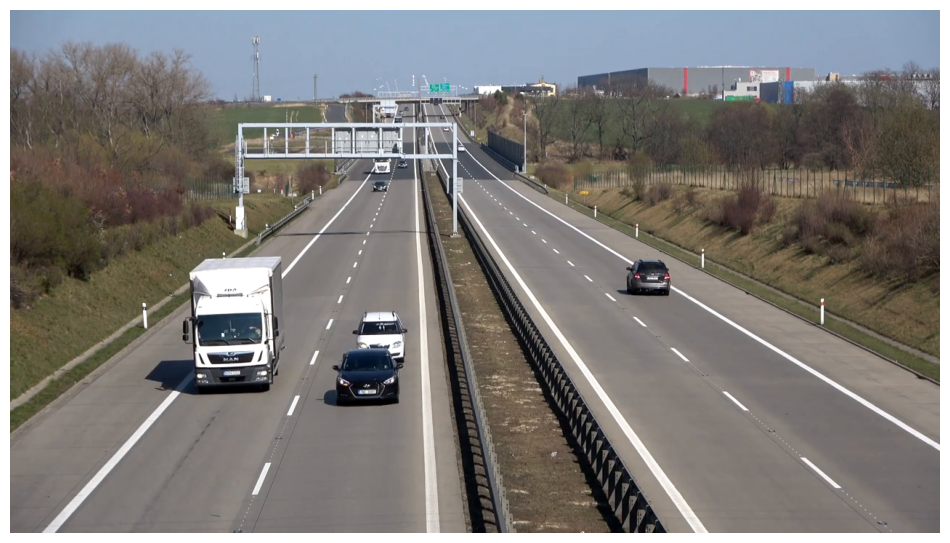

In [6]:
gerador = sv.get_video_frames_generator(str(VIDEO), start=30)
quadro = next(gerador)
gerador.close()
H, W = quadro.shape[:2]
print("Array [altura, largura, canais]:", quadro.shape)
sv.plot_image(quadro)

### Coordenadas de imagem e índices de array

Na API deste notebook, a origem $(0,0)$ está no **canto superior esquerdo**: $x$ cresce para a direita e $y$ cresce para baixo. O acesso NumPy é `quadro[y, x]`, enquanto caixas e pontos usam a ordem `(x, y)`. Essa é uma convenção raster, distinta da convenção cartesiana com origem inferior.

As caixas usam coordenadas contínuas de borda, podendo atingir $W$ e $H$. Já os índices válidos dos pixels terminam em $W-1$ e $H-1$. Não acrescentaremos `+1` ao calcular a largura ou a área de uma caixa contínua.

## Produzir detecções

Carregaremos pesos pré-treinados do **RF-DETR Medium**. Não há treinamento nesta aula. `predict` realiza o pré-processamento do modelo e devolve caixas no referencial da imagem fornecida, já organizadas como `sv.Detections`.

A confiança é uma pontuação do modelo, não uma garantia de probabilidade calibrada. O limiar `0.25` determina quais previsões serão disponibilizadas para a análise deste quadro.

In [7]:
modelo = RFDETRMedium(device=dispositivo)
modelo.inference(compile=False)
rgb = cv2.cvtColor(quadro, cv2.COLOR_BGR2RGB)
deteccoes = modelo.predict(rgb, threshold=0.25, include_source_image=False)
assert isinstance(deteccoes, sv.Detections)
print("Detecções:", len(deteccoes))

[2026-09-26 02:21:51] [INFO] rf-detr - File /root/.roboflow/models/rf-detr-medium.pth already exists with correct MD5 hash.


[2026-09-26 02:21:51] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.


[2026-09-26 02:21:51] [WARNING] rf-detr - Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.


[2026-09-26 02:21:52] [INFO] rf-detr - File /root/.roboflow/models/rf-detr-medium.pth already exists with correct MD5 hash.


Detecções: 16


## Entender `sv.Detections`

Cada linha representa uma **instância observada no quadro**. Os campos permanecem alinhados: a linha de `xyxy`, a confiança, a classe e os metadados de mesmo índice descrevem o mesmo objeto. Filtrar o objeto `Detections` preserva esse alinhamento.

| Campo | Conteúdo | Forma usual |
|:--|:--|:--|
| `xyxy` | Cantos `(x1, y1, x2, y2)` em pixels | `(N, 4)` |
| `confidence` | Pontuação de cada previsão | `(N,)` |
| `class_id` | Categoria semântica do modelo | `(N,)` |
| `data["class_name"]` | Nome da categoria, quando fornecido | `(N,)` |
| `tracker_id` | Identidade temporal, quando estimada | `(N,)` ou `None` |

**Classe não é identidade:** dois carros podem ter a mesma classe e IDs temporais diferentes. Antes do tracking, `tracker_id` normalmente é `None`.

In [8]:
print("Caixas:", deteccoes.xyxy.shape)
print(deteccoes.xyxy[:3])
print("Confiança:", deteccoes.confidence[:3])
print("Classes:", deteccoes.class_id[:3])
print("Nomes:", deteccoes["class_name"][:3])
print("IDs temporais:", deteccoes.tracker_id)

Caixas: (16, 4)
[[236.87 339.47 377.91 527.58]
 [444.28 464.32 535.75 544.08]
 [846.1  342.75 910.   393.69]]
Confiança: [0.96 0.93 0.92]
Classes: [8 3 3]
Nomes: ['truck' 'car' 'car']
IDs temporais: None


## Converter saídas de diferentes detectores

O contêiner uniforme permite trocar o detector mantendo filtros e visualizações. A conversão deve corresponder ao **objeto retornado pela biblioteca**, não ao nome comercial do modelo.

| Origem do resultado | Entrada no Supervision |
|:--|:--|
| `RFDETRMedium.predict(...)` do pacote `rfdetr` | Já retorna `sv.Detections` |
| `YOLO(...).predict(...)[0]` do pacote `ultralytics` | `sv.Detections.from_ultralytics(resultado)` |
| Resultado de Roboflow Inference | `sv.Detections.from_inference(resultado)` |
| Resultado pós-processado de Transformers | `sv.Detections.from_transformers(resultado)` |

Vamos representar uma previsão real deste quadro no esquema de resposta JSON do Inference, apenas em memória. O objetivo é verificar a adaptação de formato; não faremos uma chamada remota.

In [9]:
assert len(deteccoes) > 0, "Nenhuma detecção disponível para o exemplo."
x1, y1, x2, y2 = deteccoes.xyxy[0].astype(float)
predicao = {"x": (x1 + x2) / 2, "y": (y1 + y2) / 2,
            "width": x2 - x1, "height": y2 - y1,
            "confidence": float(deteccoes.confidence[0]),
            "class_id": int(deteccoes.class_id[0]),
            "class": str(deteccoes["class_name"][0])}
resposta = {"image": {"width": W, "height": H}, "predictions": [predicao]}
convertida = sv.Detections.from_inference(resposta)
np.testing.assert_allclose(convertida.xyxy, deteccoes.xyxy[:1], atol=1e-4)
print(convertida.xyxy)

[[236.87 339.47 377.91 527.58]]


O resultado conserva a caixa original. Os nomes `x` e `y` nessa resposta representam o **centro**, enquanto `xywh` nas utilidades geométricas do Supervision usa o **canto superior esquerdo**. A documentação do formato resolve essa ambiguidade.

## Selecionar instâncias com máscaras booleanas

Filtraremos por categoria e pontuação em uma única operação. Usar os nomes vindos do checkpoint evita supor que identificadores inteiros tenham o mesmo significado em todos os modelos.

A quantidade de detecções em um quadro não representa a quantidade de veículos únicos em um vídeo.

In [10]:
classes_veiculos = ["car", "truck", "bus", "motorcycle"]
eh_veiculo = np.isin(deteccoes["class_name"], classes_veiculos)
confiavel = deteccoes.confidence >= 0.35
veiculos = deteccoes[eh_veiculo & confiavel]
print("Todas:", len(deteccoes), "Selecionadas:", len(veiculos))
assert len(veiculos) > 0, "O filtro não selecionou veículos neste quadro."

Todas: 16 Selecionadas: 8


## Compor anotações legíveis

Anotadores operam sobre a mesma cena e podem ser encadeados. Usaremos caixas e rótulos com a mesma paleta; `frame.copy()` preserva a imagem original para outras análises. A cor representa a categoria nesta visualização, não uma identidade temporal.

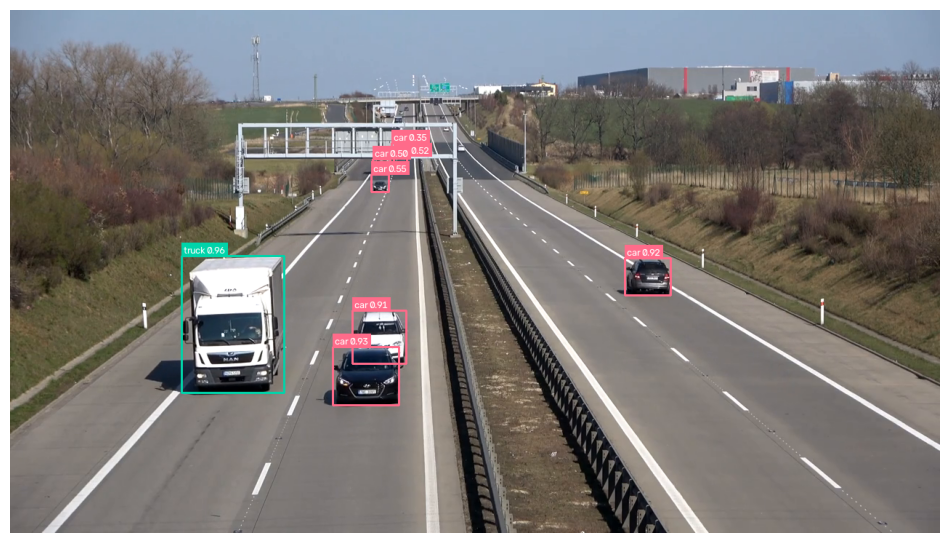

In [11]:
paleta = sv.ColorPalette.from_hex(["#00D4AA", "#4DA3FF", "#FFCC66", "#FF6B8A"])
caixas = sv.BoxAnnotator(color=paleta, thickness=2)
rotulos = sv.LabelAnnotator(color=paleta, text_scale=0.45, text_thickness=1, text_padding=3)
nomes = veiculos["class_name"]
etiquetas = [f"{nome} {score:.2f}" for nome, score
             in zip(nomes, veiculos.confidence)]
anotado = caixas.annotate(quadro.copy(), veiculos)
anotado = rotulos.annotate(anotado, veiculos, etiquetas)
sv.plot_image(anotado)
cv2.imwrite(str(SAIDAS / "deteccoes.png"), anotado);

## Converter formatos de caixa

Uma mesma região pode ter representações diferentes:

| Formato | Valores |
|:--|:--|
| `xyxy` | $(x_1, y_1, x_2, y_2)$ |
| `xywh` | $(x_1, y_1, w, h)$ |
| `cxcywh` | $(c_x, c_y, w, h)$ |

As relações são $w=x_2-x_1$, $h=y_2-y_1$, $c_x=(x_1+x_2)/2$ e $c_y=(y_1+y_2)/2$. No array de forma $(N,4)$, cada linha armazena os quatro componentes da caixa de uma instância.

In [12]:
xyxy = veiculos.xyxy.copy()
xywh = sv.xyxy_to_xywh(xyxy)
cxcywh = xywh.copy()
cxcywh[:, :2] += xywh[:, 2:] / 2
print("xyxy:", xyxy[0])
print("xywh:", xywh[0])
print("cxcywh:", cxcywh[0])

xyxy: [236.87 339.47 377.91 527.58]
xywh: [236.87 339.47 141.05 188.12]
cxcywh: [307.39 433.52 141.05 188.12]


A conversão inversa é uma verificação simples e útil: obter a mesma caixa confirma que origem e dimensões foram interpretadas corretamente. `xcycwh_to_xyxy` é o nome adotado pela API para a representação centrada.

In [13]:
reconstruida = sv.xywh_to_xyxy(xywh)
centrada_reconstruida = sv.xcycwh_to_xyxy(cxcywh)
np.testing.assert_allclose(reconstruida, xyxy, atol=1e-4)
np.testing.assert_allclose(centrada_reconstruida, xyxy, atol=1e-4)
print("Conversões verificadas.")

Conversões verificadas.


## Normalizar e recuperar coordenadas

Coordenadas normalizadas expressam posições como frações da largura e da altura. Para caixas `xyxy`, dividimos por $(W,H,W,H)$, nessa ordem. Essa normalização depende do tamanho da imagem e não produz coordenadas métricas no mundo.

Da mesma forma, `cxcywh` normalizado usa $(c_x/W,c_y/H,w/W,h/H)$. A conversão de formato e a normalização são operações distintas.

In [14]:
escala = np.array([W, H, W, H], dtype=np.float32)
xyxy_normalizado = xyxy / escala
cxcywh_normalizado = cxcywh / escala
np.testing.assert_allclose(xyxy_normalizado * escala, xyxy, atol=1e-4)
print("xyxy normalizado:", xyxy_normalizado[0])
print("cxcywh normalizado:", cxcywh_normalizado[0])

xyxy normalizado: [0.19 0.47 0.3  0.73]
cxcywh normalizado: [0.24 0.6  0.11 0.26]


## Redimensionar a imagem e suas caixas

Ao redimensionar uma imagem, as caixas precisam acompanhar a transformação. Na operação abaixo não há corte nem preenchimento: multiplicamos os eixos pelos fatores `nova_largura / W` e `nova_altura / H`.

Redimensionamento com **letterbox** acrescenta deslocamentos de padding; recortes também alteram a origem. Nesses casos, apenas multiplicar pela escala é insuficiente. Um conversor de formato não corrige automaticamente essas transformações.

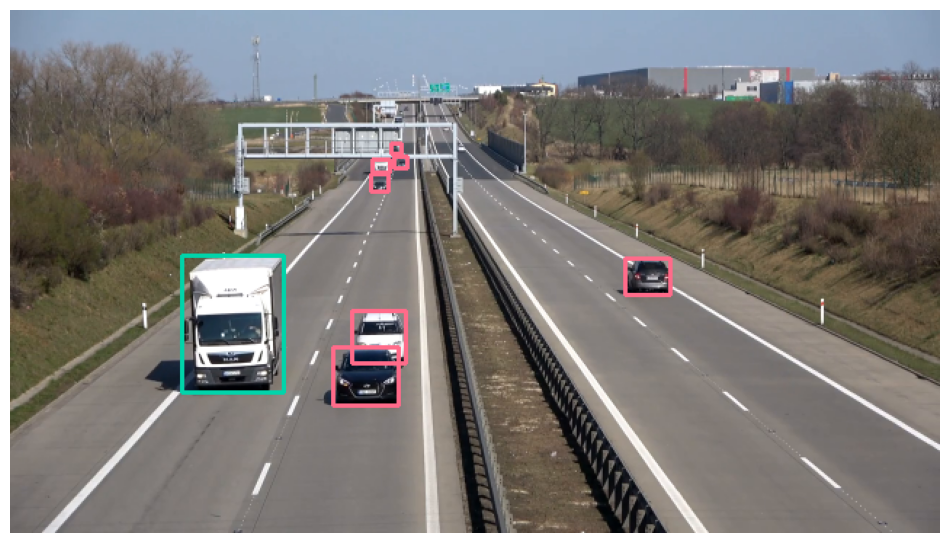

In [15]:
nova_largura, nova_altura = W // 2, H // 2
reduzido = cv2.resize(quadro, (nova_largura, nova_altura))
fatores = np.array([nova_largura / W, nova_altura / H] * 2)
caixas_reduzidas = xyxy * fatores
veiculos_reduzidos = sv.Detections(xyxy=caixas_reduzidas,
    confidence=veiculos.confidence, class_id=veiculos.class_id)
visual_reduzido = caixas.annotate(reduzido.copy(), veiculos_reduzidos)
sv.plot_image(visual_reduzido)
np.testing.assert_allclose(caixas_reduzidas / fatores, xyxy, atol=1e-4)

### Distinguir escala e deslocamento

Se uma imagem é redimensionada por um fator uniforme $s$ e recebe bordas de largura $p_x$ e $p_y$ à esquerda e acima, um ponto é transformado por $x'=sx+p_x$ e $y'=sy+p_y$. A inversa subtrai o padding antes de dividir pela escala.

A seguir, verificamos a relação numericamente em uma caixa real, sem executar uma nova inferência nem alterar a imagem.

In [16]:
s, px, py = 0.5, 20.0, 40.0
deslocamento = np.array([px, py, px, py])
caixa_com_padding = xyxy[:1] * s + deslocamento
caixa_recuperada = (caixa_com_padding - deslocamento) / s
np.testing.assert_allclose(caixa_recuperada, xyxy[:1], atol=1e-4)
print("Com padding:", caixa_com_padding[0])
print("Recuperada:", caixa_recuperada[0])

Com padding: [138.43 209.73 208.96 303.79]
Recuperada: [236.87 339.47 377.91 527.58]


## Escolher um ponto de ancoragem

Uma caixa não é um ponto. O **centro** é útil para representar veículos vistos de cima; o **centro inferior** pode aproximar o contato de pessoas com o solo em uma câmera oblíqua. Nenhuma dessas escolhas garante a posição física exata do objeto.

As âncoras extraídas por Supervision permanecem no referencial de pixels da caixa. Compararemos as duas escolhas sobre o mesmo conjunto de detecções.

Centro: [307.39 433.52]
Centro inferior: [307.39 527.58]


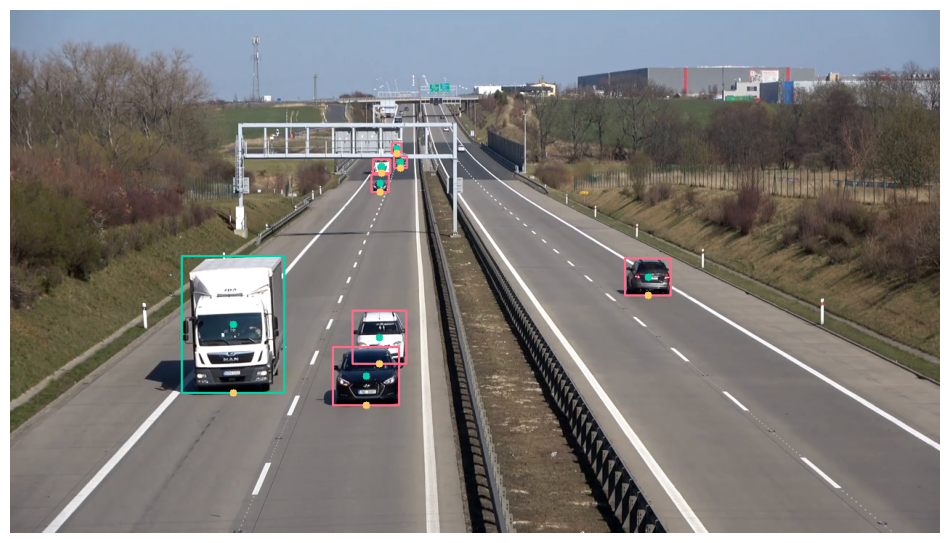

In [17]:
centros = veiculos.get_anchors_coordinates(sv.Position.CENTER)
bases = veiculos.get_anchors_coordinates(sv.Position.BOTTOM_CENTER)
print("Centro:", centros[0])
print("Centro inferior:", bases[0])
pontos_centrais = sv.DotAnnotator(color="#00D4AA", radius=5)
pontos_inferiores = sv.DotAnnotator(color="#FFCC66", radius=5,
    position=sv.Position.BOTTOM_CENTER)
com_ancoras = caixas.annotate(quadro.copy(), veiculos)
com_ancoras = pontos_centrais.annotate(com_ancoras, veiculos)
com_ancoras = pontos_inferiores.annotate(com_ancoras, veiculos)
sv.plot_image(com_ancoras)

Verde indica o centro e amarelo indica o centro inferior. Alterar a âncora desloca o ponto consultado por uma regra espacial; por isso pode modificar o instante de entrada em uma zona ou de cruzamento de uma linha.

## Usar a geometria para uma anotação condicional

Uma região de interesse permite destacar as detecções cujo ponto de ancoragem está dentro de um polígono. Escolheremos uma área didática na metade inferior da imagem; ela não representa uma faixa viária calibrada.

`PolygonZone.trigger` devolve uma máscara booleana por instância. Neste exemplo ela descreve pertencimento **no quadro atual**; não mede veículos únicos nem fluxo acumulado.

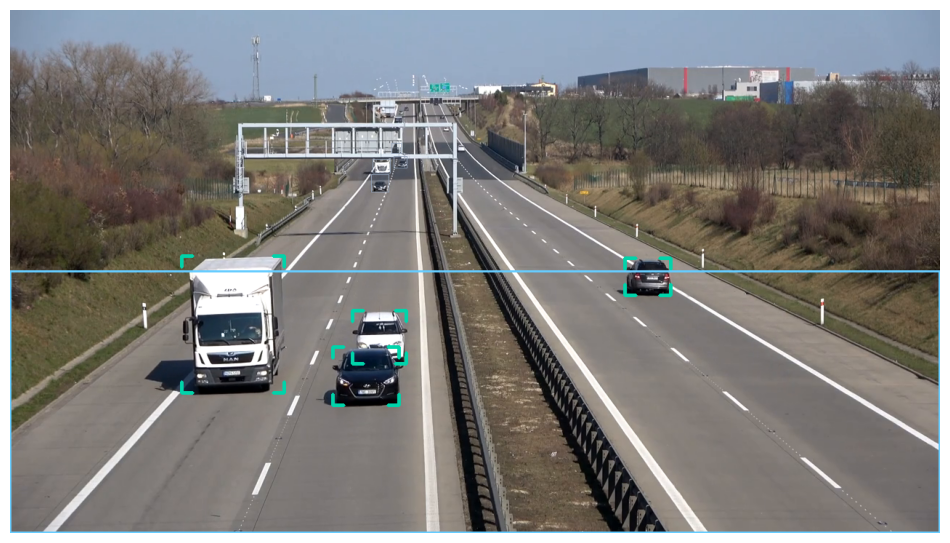

In [18]:
poligono = np.array([[0, H // 2], [W - 1, H // 2],
                     [W - 1, H - 1], [0, H - 1]])
zona = sv.PolygonZone(polygon=poligono,
    triggering_anchors=(sv.Position.CENTER,))
dentro = zona.trigger(veiculos)
realce = sv.BoxCornerAnnotator(color="#00D4AA", thickness=3)
discretas = sv.BoxAnnotator(color="#94A3B8", thickness=1)
condicional = discretas.annotate(quadro.copy(), veiculos[~dentro])
condicional = realce.annotate(condicional, veiculos[dentro])
cv2.polylines(condicional, [poligono], True, (255, 204, 102), 2)
sv.plot_image(condicional)

A seleção, a geometria e o desenho são responsabilidades separadas. Podemos preservar as detecções e trocar apenas a forma de comunicar o resultado. Uma visualização bem resolvida facilita a inspeção, mas não valida a precisão do detector.

## Verificar a compreensão

- Aumente o limiar de confiança e identifique quais veículos deixam de aparecer. Uma previsão removida era necessariamente incorreta?
- Substitua `CENTER` por `BOTTOM_CENTER` na zona e compare a máscara booleana. Explique qualquer diferença usando a geometria das caixas.
- Calcule a área de uma caixa antes e depois de reduzir largura e altura à metade. Por que a área fica aproximadamente quatro vezes menor?
- Explique por que coordenadas normalizadas não permitem estimar a velocidade em km/h sem calibração adicional.

No próximo notebook, acrescentaremos o estado temporal: a associação de detecções em quadros sucessivos permitirá estimar identidades e desenhar trajetórias.

## Referências

- [Detections e adaptadores](https://supervision.roboflow.com/latest/detection/core/)
- [Conversores geométricos](https://supervision.roboflow.com/latest/detection/utils/converters/)
- [Anotadores](https://supervision.roboflow.com/latest/detection/annotators/)
- [Anotações condicionais no blog Roboflow](https://blog.roboflow.com/create-conditional-annotators/)
- [RF-DETR: inferência](https://rfdetr.roboflow.com/latest/learn/run/detection/)

Consulta das fontes: 26/09/2026. A lista comentada e os critérios de atualização estão em `REFERENCIAS.md`.